# Ammonia financial-metric summary

Compare deterministic and aligned Monte Carlo results for all seven greenfield ammonia routes and both CCS add-ons using NPV, levelized profit margin, or LCOA (the ammonia LCOX). The paired bar charts share one scale for the selected metric. The CCS routes resolve against their parent technologies. Figures and tables display inline; this notebook does not save files.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from ammonia.ammonia_npv_deterministic import calculate_deterministic_ammonia_results
from ammonia.ammonia_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_ammonia_results,
)
from ammonia.ammonia_npv_summary_figures import (
    AMMONIA_FINANCIAL_METRIC_OPTIONS,
    AMMONIA_TECHNOLOGY_LABELS,
    calculate_ammonia_npv_rankings_from_results,
)
from npv_summary import summarize_metric_signs
from npv_summary_plots import (
    plot_average_rank_bars,
    plot_financial_metric_technology_bars,
    shared_financial_metric_bar_axis_config,
)


## Settings

In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE
TECHNOLOGIES = tuple(AMMONIA_TECHNOLOGY_LABELS)
FINANCIAL_METRIC = "LPM"  # "NPV", "LPM", or "LCOX"

if FINANCIAL_METRIC not in AMMONIA_FINANCIAL_METRIC_OPTIONS:
    raise ValueError(f"Unknown FINANCIAL_METRIC: {FINANCIAL_METRIC!r}")

METRIC_CONFIG = AMMONIA_FINANCIAL_METRIC_OPTIONS[FINANCIAL_METRIC]
METRIC_COLUMN = str(METRIC_CONFIG["metric_column"])
METRIC_SCALE_FACTOR = float(METRIC_CONFIG["scale"])
METRIC_SUMMARY_COLUMN = str(METRIC_CONFIG["summary_column"])
METRIC_AXIS_LABEL = str(METRIC_CONFIG["axis_label"])
METRIC_RANKING_LABEL = str(METRIC_CONFIG["ranking_label"])
METRIC_HIGHER_IS_BETTER = bool(METRIC_CONFIG["higher_is_better"])
METRIC_COLOR_BY_SIGN = bool(METRIC_CONFIG["color_by_sign"])
METRIC_ZERO_BASELINE = bool(METRIC_CONFIG["zero_baseline"])
METRIC_AXIS_TICK_STEP = METRIC_CONFIG.get("axis_tick_step")

pd.options.display.float_format = "{:,.3f}".format


## Monte Carlo financial-metric distribution

,label,technology_type,levelized_profit_margin_eur_per_tnh3,median,p05,p95,non_negative_count,negative_count,non_negative_share
7,NG-SMR + HB + CCS,retrofit,331.025,343.026,110.519,510.685,99545,455,0.995
0,NG-SMR + HB,absolute,268.889,280.989,48.644,448.383,97885,2115,0.979
4,Methane pyrolysis + HB,absolute,94.504,107.263,-171.121,319.085,73621,26379,0.736
3,Biomass gasification + HB,absolute,94.004,96.887,-50.875,229.726,85662,14338,0.857
8,Coal gasification + HB + CCS,retrofit,91.498,92.172,4.086,176.172,95760,4240,0.958
1,Coal gasification + HB,absolute,-28.547,-27.500,-106.371,45.668,27817,72183,0.278
2,AEL/PEM electrolysis + HB,absolute,-439.585,-438.212,-825.633,-55.581,2039,97961,0.020
5,SOEC + HB,absolute,-486.481,-485.648,-818.245,-157.137,66,99934,0.001
6,Aqueous direct NRR,absolute,"-1,933.332","-1,930.215","-2,671.950","-1,203.603",0,100000,0.000


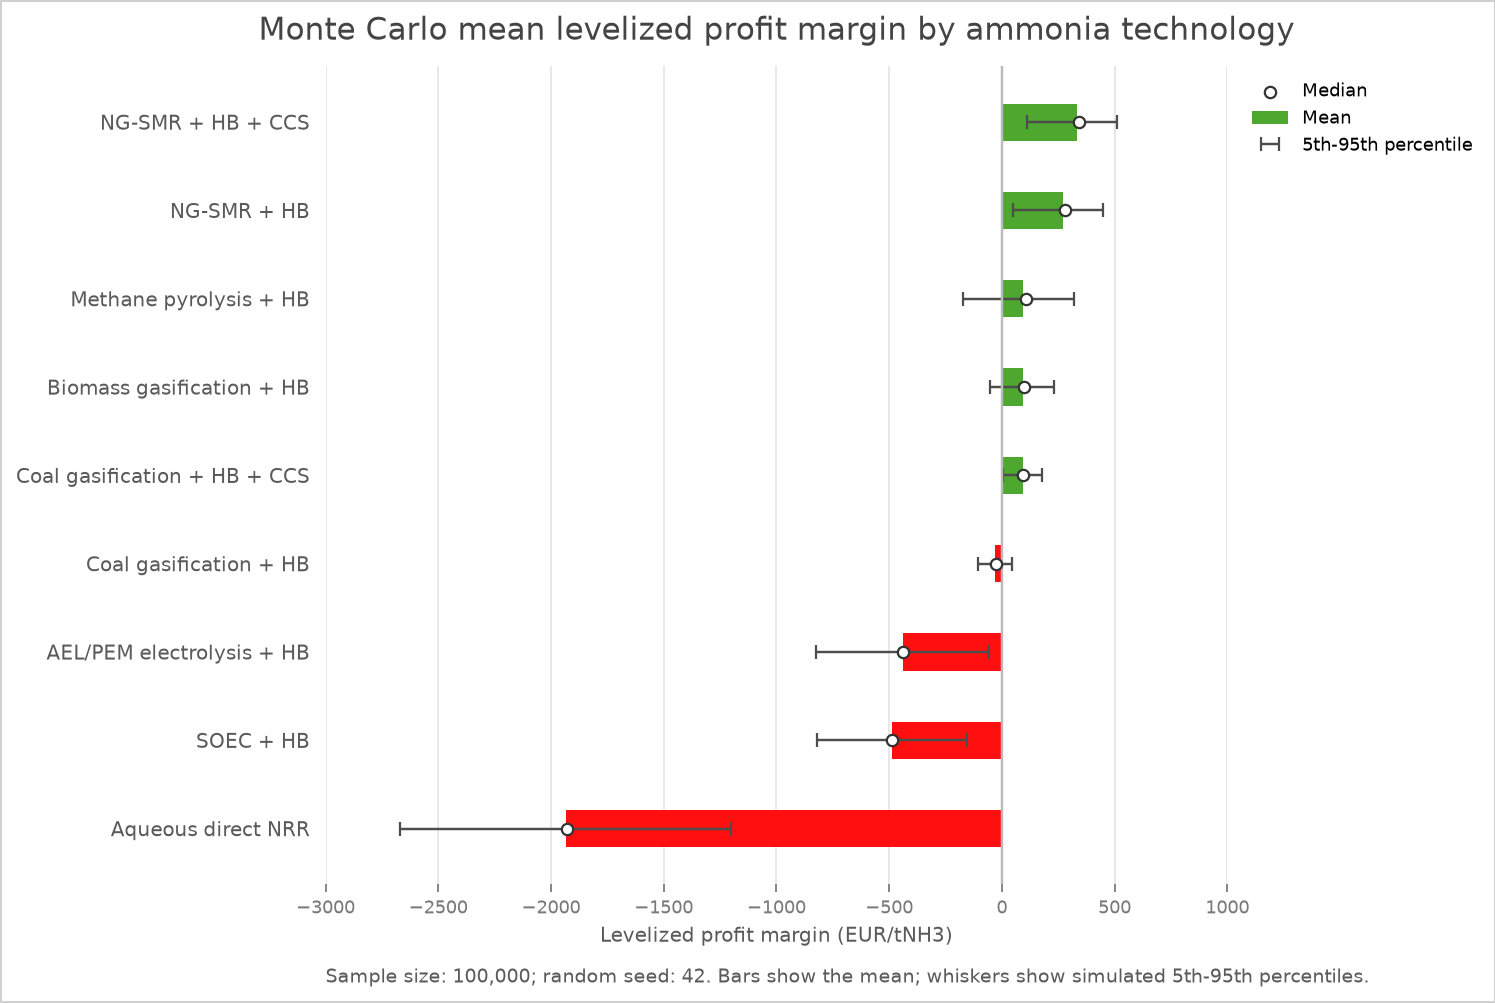

In [3]:
monte_carlo_results = simulate_ammonia_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=TECHNOLOGIES,
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)

mc_summary_rows = []
for technology, results in monte_carlo_results.items():
    values = np.asarray(results[METRIC_COLUMN], dtype=float) / METRIC_SCALE_FACTOR
    mc_summary_rows.append(
        {
            "label": AMMONIA_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: values.mean(),
            "median": np.median(values),
            "p05": np.percentile(values, 5),
            "p95": np.percentile(values, 95),
            **summarize_metric_signs(values),
        }
    )
mc_summary = pd.DataFrame(mc_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)
mc_summary_by_label = mc_summary.set_index("label")

deterministic_results = calculate_deterministic_ammonia_results(technologies=TECHNOLOGIES)
det_summary_rows = []
for technology, results in deterministic_results.items():
    det_summary_rows.append(
        {
            "label": AMMONIA_TECHNOLOGY_LABELS.get(technology, technology),
            "technology_type": str(np.asarray(results["technology_type"])[0]),
            METRIC_SUMMARY_COLUMN: (
                float(np.asarray(results[METRIC_COLUMN]).item()) / METRIC_SCALE_FACTOR
            ),
        }
    )
det_summary = pd.DataFrame(det_summary_rows).sort_values(
    METRIC_SUMMARY_COLUMN, ascending=not METRIC_HIGHER_IS_BETTER
)
det_summary_by_label = det_summary.set_index("label")

BAR_X_AXIS_LIMITS, BAR_X_AXIS_TICKS = shared_financial_metric_bar_axis_config(
    distribution_summary=mc_summary_by_label[["p05", "p95"]].to_dict(orient="index"),
    deterministic_values=det_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    zero_floor=METRIC_ZERO_BASELINE,
    tick_step=METRIC_AXIS_TICK_STEP,
)

display(mc_summary)
plot_financial_metric_technology_bars(
    values=mc_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Monte Carlo mean {METRIC_RANKING_LABEL} by ammonia technology",
    median_values=mc_summary_by_label["median"].to_dict(),
    lower_values=mc_summary_by_label["p05"].to_dict(),
    upper_values=mc_summary_by_label["p95"].to_dict(),
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
    x_axis_limits=BAR_X_AXIS_LIMITS,
    x_axis_ticks=BAR_X_AXIS_TICKS,
)
plt.show()


## Deterministic financial metric

,label,technology_type,levelized_profit_margin_eur_per_tnh3
7,NG-SMR + HB + CCS,retrofit,330.513
0,NG-SMR + HB,absolute,268.377
3,Biomass gasification + HB,absolute,94.267
4,Methane pyrolysis + HB,absolute,93.745
8,Coal gasification + HB + CCS,retrofit,91.431
1,Coal gasification + HB,absolute,-28.615
2,AEL/PEM electrolysis + HB,absolute,-439.402
5,SOEC + HB,absolute,-486.570
6,Aqueous direct NRR,absolute,"-1,933.107"


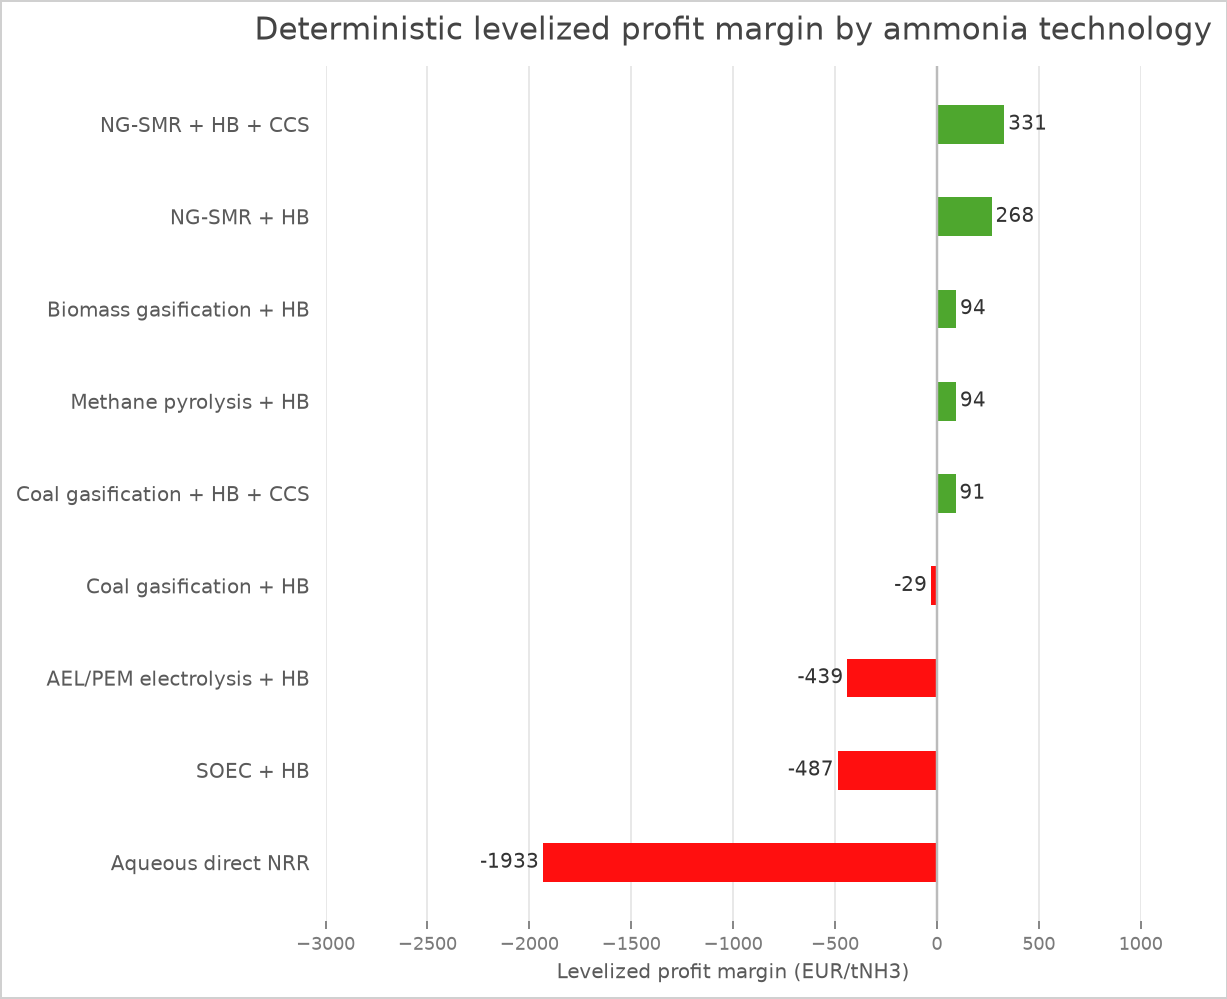

In [4]:
display(det_summary)
plot_financial_metric_technology_bars(
    values=det_summary_by_label[METRIC_SUMMARY_COLUMN].to_dict(),
    output_path=None,
    title=f"Deterministic {METRIC_RANKING_LABEL} by ammonia technology",
    x_axis_label=METRIC_AXIS_LABEL,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
    color_by_sign=METRIC_COLOR_BY_SIGN,
    zero_baseline=METRIC_ZERO_BASELINE,
    x_axis_limits=BAR_X_AXIS_LIMITS,
    x_axis_ticks=BAR_X_AXIS_TICKS,
)
plt.show()


## Monte Carlo financial-metric ranking

,Technology,Average rank,Probability rank 1,Probability top 3,Simulations
0,NG-SMR + HB + CCS,1.113,0.918,0.996,100000
1,NG-SMR + HB,2.253,0.000,0.929,100000
2,Coal gasification + HB + CCS,3.907,0.028,0.277,100000
3,Biomass gasification + HB,3.920,0.054,0.353,100000
4,Methane pyrolysis + HB,4.161,0.000,0.439,100000
5,Coal gasification + HB,5.684,0.000,0.006,100000
6,AEL/PEM electrolysis + HB,7.241,0.000,0.000,100000
7,SOEC + HB,7.720,0.000,0.000,100000
8,Aqueous direct NRR,9.000,0.000,0.000,100000


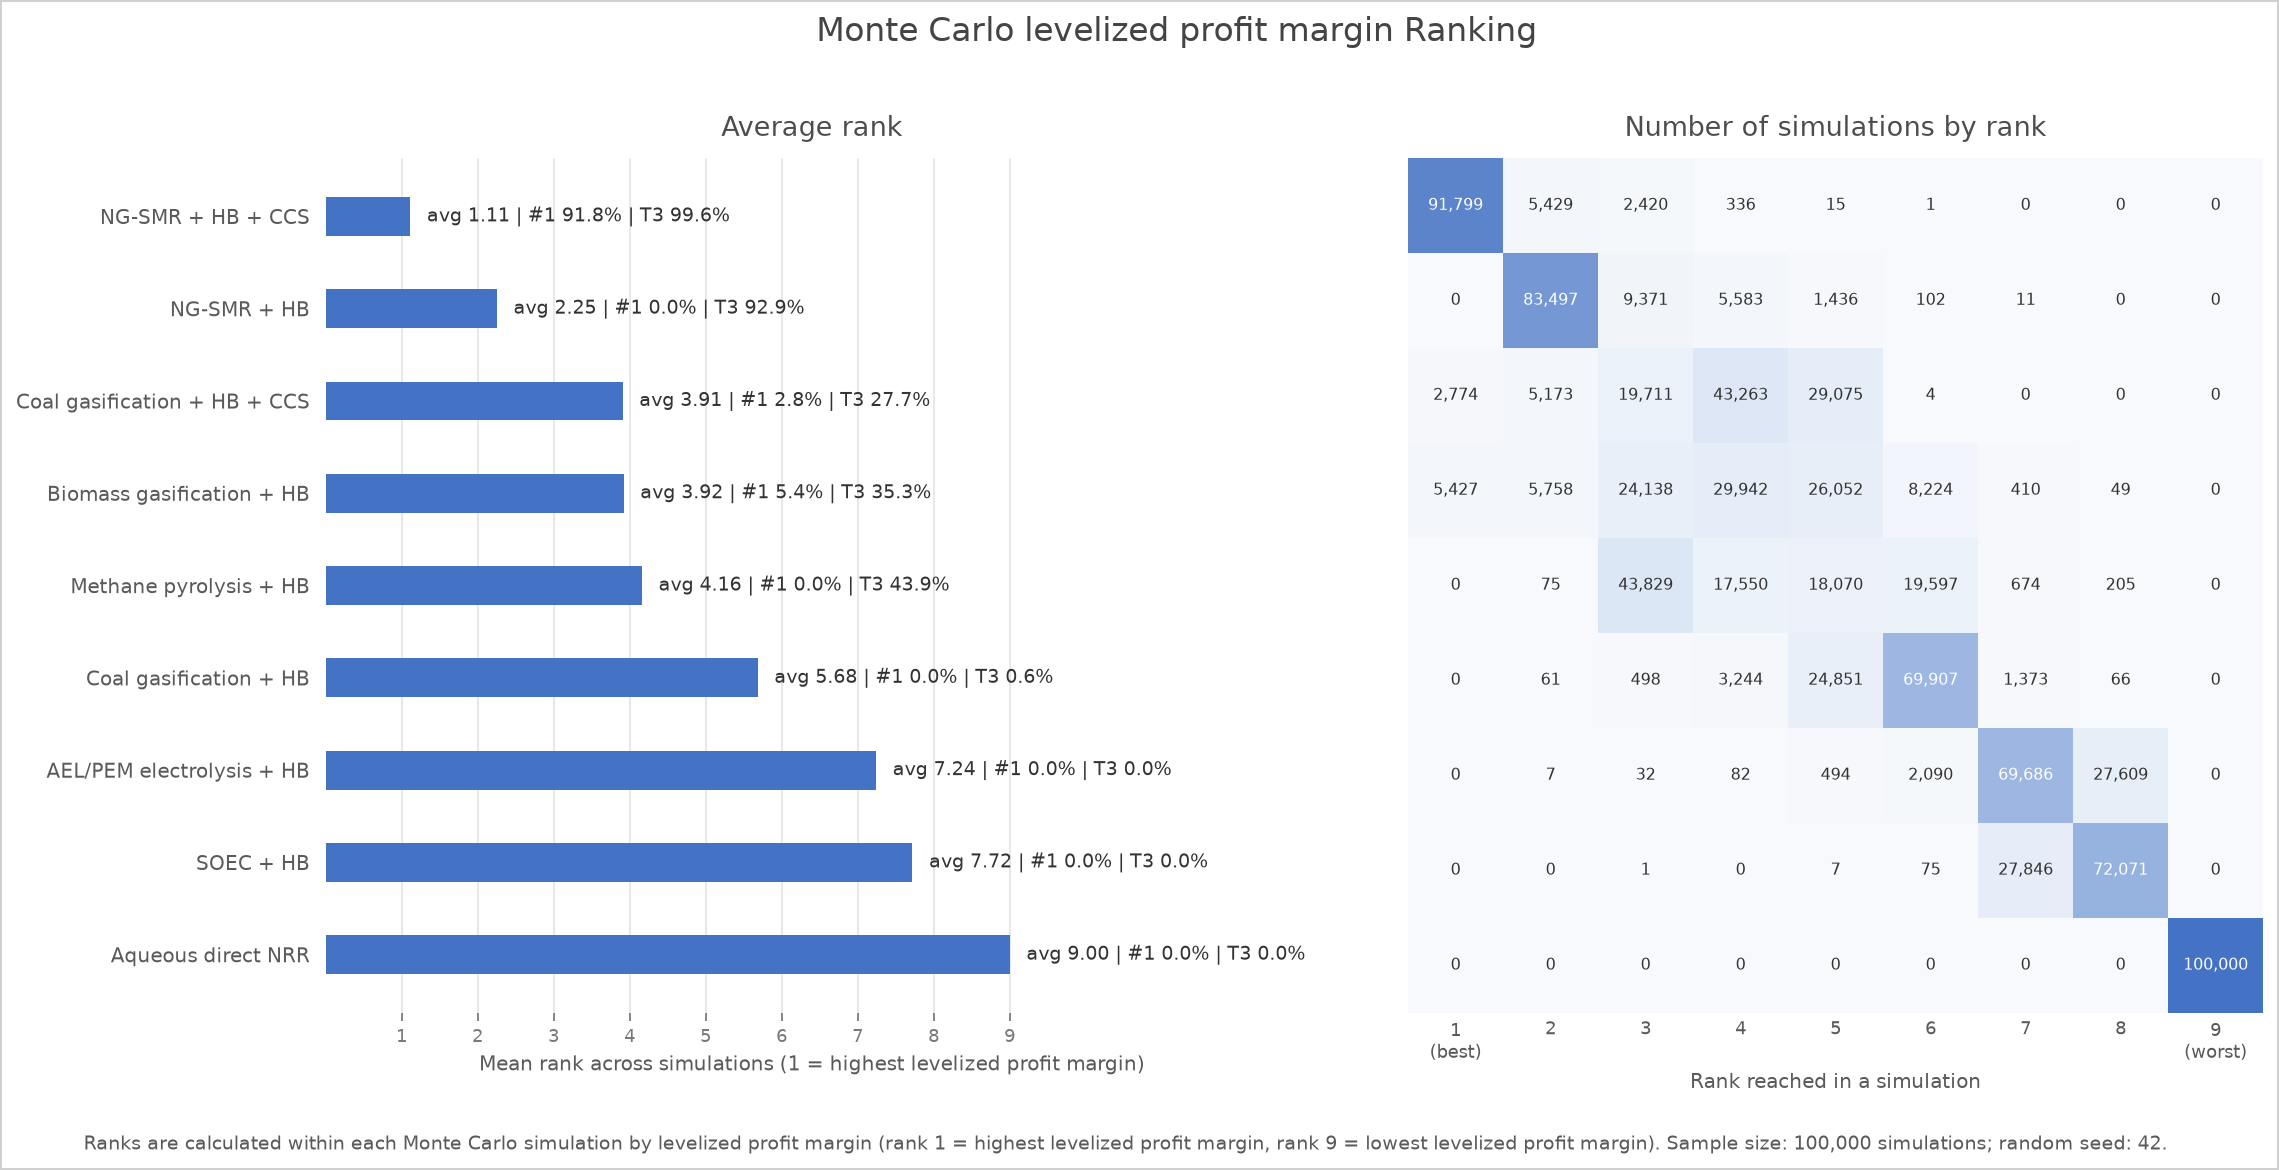

In [5]:
ranking_raw, ranking_summary = calculate_ammonia_npv_rankings_from_results(
    results=monte_carlo_results,
    sector_name="Ammonia",
    financial_metric=FINANCIAL_METRIC,
)

ranking_summary_for_plot = ranking_summary.assign(
    display_label=ranking_summary["technology"].map(AMMONIA_TECHNOLOGY_LABELS).fillna(ranking_summary["technology"])
)
rank_table = (
    ranking_summary_for_plot.rename(columns={"display_label": "Technology"})
    .loc[:, ["Technology", "average_rank", "probability_rank_1", "probability_top_3", "n_simulations"]]
    .rename(
        columns={
            "average_rank": "Average rank",
            "probability_rank_1": "Probability rank 1",
            "probability_top_3": "Probability top 3",
            "n_simulations": "Simulations",
        }
    )
)
display(rank_table)
plot_average_rank_bars(
    ranking_summary=ranking_summary_for_plot,
    output_path=None,
    title=f"Monte Carlo {METRIC_RANKING_LABEL} Ranking",
    metric_label=METRIC_RANKING_LABEL,
    random_seed=RANDOM_SEED,
    higher_is_better=METRIC_HIGHER_IS_BETTER,
)
plt.show()
